<a href="https://colab.research.google.com/github/jhughes7386/cosc-650-applied-llm-systems/blob/week-02/week-02/week2_inference_sampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 (starter): Inference and Sampling

Runs as-is on a small local model so you can see each stage; cells marked **TODO (you)** are where you do the work. No GPU, no API key. Dependencies: `transformers`, `torch` (CPU), `numpy`, `matplotlib`.

Parts: trace the forward pass, build the sampling explorer, evaluate three settings, find one failure, submit.

In [1]:
# Setup. In Colab: !pip install transformers torch numpy matplotlib
import os, pathlib
os.environ['HF_HOME'] = str((pathlib.Path('.') / '.hf_cache').resolve())
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
torch.manual_seed(0)
name = 'distilgpt2'
tok = AutoTokenizer.from_pretrained(name)
model = AutoModelForCausalLM.from_pretrained(name, attn_implementation='eager')  # eager so attention is returned
model.eval()
cfg = model.config
print(f'{name}: {cfg.n_layer} layers, {cfg.n_head} heads, embed dim {cfg.n_embd}, vocab {cfg.vocab_size}')

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

distilgpt2: 6 layers, 12 heads, embed dim 768, vocab 50257


## Part 1: Trace the forward pass
**TODO (you):** change the prompt to your own. Read off the real numbers at each stage.

In [2]:
prompt = 'The NFL team in Missouri is the'   # TODO (you): your own short prompt
enc = tok(prompt, return_tensors='pt')
ids = enc['input_ids'][0]
print('token IDs:', ids.tolist())
for i, t in enumerate(ids.tolist()):
    print(f'  pos {i}: id {t:6d} -> {tok.decode([t])!r}')

emb = model.transformer.wte(ids)
print('\nembedded prompt shape (seq_len, dim):', tuple(emb.shape))

with torch.no_grad():
    out = model(**enc, output_attentions=True)
att = out.attentions[0][0, 0, -1]   # layer 0, head 0, last token attends to...
print('last-token attention (layer 0, head 0), sums to', round(att.sum().item(), 4))
for j in range(ids.shape[0]):
    print(f'  {tok.decode([ids[j]])!r:12s} {att[j].item():.3f}')

with torch.no_grad():
    logits = model(**enc).logits
print('\nlogits shape (batch, seq, vocab):', tuple(logits.shape))
probs = torch.softmax(logits[0, -1], dim=-1)
top = torch.topk(probs, 10)
print('top 10 next tokens:')
for p, idx in zip(top.values.tolist(), top.indices.tolist()):
    print(f'  {tok.decode([idx])!r:14s} {p:.4f}')
next_logits = logits[0, -1]

token IDs: [464, 5134, 1074, 287, 11565, 318, 262]
  pos 0: id    464 -> 'The'
  pos 1: id   5134 -> ' NFL'
  pos 2: id   1074 -> ' team'
  pos 3: id    287 -> ' in'
  pos 4: id  11565 -> ' Missouri'
  pos 5: id    318 -> ' is'
  pos 6: id    262 -> ' the'

embedded prompt shape (seq_len, dim): (7, 768)
last-token attention (layer 0, head 0), sums to 1.0
  'The'        0.404
  ' NFL'       0.151
  ' team'      0.134
  ' in'        0.058
  ' Missouri'  0.120
  ' is'        0.078
  ' the'       0.055

logits shape (batch, seq, vocab): (1, 7, 50257)
top 10 next tokens:
  ' only'        0.1560
  ' first'       0.0591
  ' most'        0.0435
  ' best'        0.0390
  ' team'        0.0382
  ' second'      0.0370
  ' third'       0.0315
  ' No'          0.0313
  ' latest'      0.0308
  ' NFL'         0.0230


### Forward Pass Observation

The prompt is split into 7 tokens, each with a corresponding ID. The embedded output has the shape `(7, 768)`, meaning each token has a 768-dimensional embedding.

In the attention example, the highest weight is placed on the first word, `"The"`, with a value of 0.404. The weights are not distributed evenly across the prompt for layer 0 and head 0 because this particular attention head is focusing more heavily on earlier parts of the sentence.

The logits produced a shape of `(1, 7, 50257)`. This shows the model has 7 tokens in the prompt and a vocabulary of 50,257 possible tokens. Using softmax on the logits, the model's highest prediction for the next token is `"only"` with a probability of 0.1560. The attention weights also show that `"NFL"` (0.151) and `"Missouri"` (0.120) received less attention than `"The"` (0.404) in this particular layer and head. This may help explain why the model did not strongly predict the expected team name, although the final prediction is based on the model's full set of computations rather than attention alone.


## Part 2: Build the sampling explorer
Temperature, top-k, and top-p over the model's real next-token distribution.

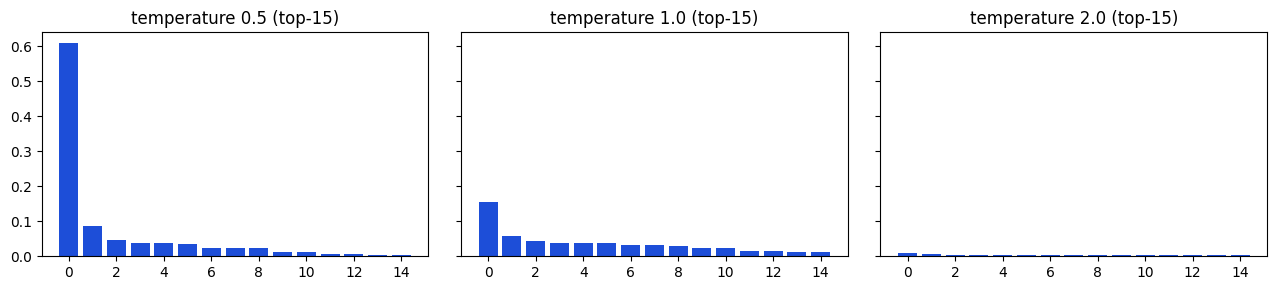

top token prob: temp 0.5 = 0.609, temp 1.0 = 0.156, temp 2.0 = 0.009


In [3]:
import numpy as np, matplotlib.pyplot as plt
z = next_logits.detach().numpy()

def softmax(x):
    x = x - x.max(); e = np.exp(x); return e / e.sum()
def temperature(z, t):
    return softmax(z / t)
def top_k(p, k):
    out = np.zeros_like(p); idx = np.argsort(p)[::-1][:k]; out[idx] = p[idx]; return out / out.sum()
def top_p(p, thresh):
    order = np.argsort(p)[::-1]; cdf = np.cumsum(p[order]); cut = np.searchsorted(cdf, thresh) + 1
    out = np.zeros_like(p); out[order[:cut]] = p[order[:cut]]; return out / out.sum(), cut

base = softmax(z)
fig, axes = plt.subplots(1, 3, figsize=(13, 3), sharey=True)
for ax, t in zip(axes, [0.5, 1.0, 2.0]):
    pt = temperature(z, t)
    ax.bar(range(15), np.sort(pt)[::-1][:15], color='#1d4ed8')
    ax.set_title(f'temperature {t} (top-15)')
plt.tight_layout(); plt.show()
print('top token prob: temp 0.5 = %.3f, temp 1.0 = %.3f, temp 2.0 = %.3f' % (
    temperature(z,0.5).max(), temperature(z,1.0).max(), temperature(z,2.0).max()))

### Temperature Observations

The temperature setting had a noticeable effect on how concentrated the probability distribution was. At a temperature of 0.5, the top token had a probability of 0.609, while the remaining tokens decreased quickly, creating a large gap between the most likely token and the rest of the distribution. At a temperature of 1.0, the probabilities were more evenly distributed, with the highest token having a probability of 0.156. At a temperature of 2.0, the probabilities were much more spread out, with the top token having a probability of only 0.009 and the tokens having more similar probabilities.

The results show that lower temperatures make the distribution more concentrated around the highest-probability tokens, while higher temperatures make the distribution more evenly spread out.


## Part 3: Evaluate three settings with real figures
Predict first, then read the entropy, the maximum probability, and how many tokens survive.

In [4]:
def entropy(p):
    p = p[p > 0]; return float(-(p * np.log(p)).sum())
for t, tp in [(1e-6, 1.0), (0.7, 1.0), (1.3, 0.9)]:
    p = temperature(z, t)
    _, kept = top_p(p, tp)
    print(f'temp {t:<6} top-p {tp}: entropy {entropy(p):.3f}, max prob {p.max():.3f}, nucleus keeps {kept} tokens')
# TODO (you): for each row, write what you predicted versus what you see.

temp 1e-06  top-p 1.0: entropy -0.000, max prob 1.000, nucleus keeps 1 tokens
temp 0.7    top-p 1.0: entropy 2.882, max prob 0.364, nucleus keeps 50258 tokens
temp 1.3    top-p 0.9: entropy 6.787, max prob 0.062, nucleus keeps 3201 tokens


In [5]:
# add a setting that includes top-k
t, k, tp = 1.3, 20, 0.9
p = temperature(z, t)
p = top_k(p, k)
p, kept = top_p(p, tp)
print(f'temp {t:<6} top-k {k:<3} top-p {tp}: entropy {entropy(p):.3f}, max prob {p.max():.3f}, nucleus keeps {kept} tokens')

temp 1.3    top-k 20  top-p 0.9: entropy 2.609, max prob 0.202, nucleus keeps 16 tokens


### Prediction vs. Measured Result

* **Temperature 1e-6, top-p 1.0:** I predicted that the very low temperature would result in a distribution concentrated around one token. The entropy was approximately 0 and the maximum probability was 1.000, confirming this prediction.

* **Temperature 0.7, top-p 1.0:** I predicted that a lower temperature would create a more concentrated distribution, with lower entropy and a higher maximum probability than the original distribution. The entropy was 2.882 and the maximum probability was 0.364, showing that the token distribution was more concentrated. I was a little surprised by how much lower the maximum probability was compared to the 0.609 maximum probability from the 0.5 temperature in Part 2. This showed me that temperature can have a bigger effect on the probability distribution than I expected.

* **Temperature 1.3, top-p 0.9:** I predicted that the higher temperature would spread the probabilities more evenly while having fewer tokens than the previous example because of the lower top-p value. The entropy was 6.787 and the maximum probability was 0.062, while top-p kept 3,201 tokens. This showed a more even distribution with a smaller set of tokens available for sampling, but I was surprised by how much lowering top-p by 0.1 affected the number of tokens. I expected it might remove a few thousand tokens, rather than removing enough to leave only 3,201.

* **Temperature 1.3, top-k 20, top-p 0.9:** I predicted that adding top-k = 20 would reduce the number of tokens available compared to the previous setting, but I expected the higher temperature to still allow a larger number of tokens. The entropy was 2.609 and the maximum probability was 0.202, while only 16 tokens remained. I was surprised by how much adding top-k changed the distribution, especially since the previous setting with the same temperature and top-p kept 3,201 tokens. This showed me that combining sampling settings can have a much larger effect than using temperature and top-p alone.

These experiments showed me how significant these sampling arguments are and how dramatically they can change a model's output distribution. It also showed me that there is a tradeoff between a highly predictable output and considering a variety of possible tokens. Tuning the best temperature, top-k, and top-p settings would depend on the desired result, rather than simply choosing the settings with the highest or lowest values.


## Part 4: Find one failure and explain it (required)
**TODO (you):** show one surprising case and explain the cause and mitigation. A starter is below.

In [6]:
# starter failure: near-zero temperature collapses to a single token
p0 = temperature(z, 1e-6)
print('temp -> 0: top token prob =', round(p0.max(), 6), '(greedy collapse)\n')

# TODO (you): find your own surprising case (e.g. top-p = 1.0 keeps the whole vocab) and explain it.
p1 = temperature(z, 1.0) # keep temperature constant to experiment with top k

for k in [5, 10, 15, 20]:
    pk = top_k(p1, k)
    pp, kept = top_p(pk, 0.9)
    print(f'top-k = {k}, top-p = 0.9: tokens kept = {kept}')

temp -> 0: top token prob = 1.0 (greedy collapse)

top-k = 5, top-p = 0.9: tokens kept = 5
top-k = 10, top-p = 0.9: tokens kept = 9
top-k = 15, top-p = 0.9: tokens kept = 11
top-k = 20, top-p = 0.9: tokens kept = 14


### Failure Cases

#### Failure Case 1: Near-Zero Temperature

Given the sample temperature (1e-6), an extremely low temperature caused the probability distribution to collapse to a single token, giving the top token a probability of 1.0.

**Cause:** The very small temperature causes the highest-probability token to dominate the distribution instead of allowing for a wider sample of possible tokens.

**Mitigation:** Use a higher temperature when more variation in the possible tokens is desired.

#### Failure Case 2: Top-k and Top-p Interaction

I experimented with increasing top-k, thinking the number of tokens would continue to stay around a similar amount to the top-k value. I kept top-p at 0.9 for consistency and found that increasing top-k from 5 to 20 only marginally increased the number of remaining tokens from 5 to 14.

**Observed Results:**

* Top-k = 5 → 5 tokens remaining
* Top-k = 10 → 9 tokens remaining
* Top-k = 15 → 11 tokens remaining
* Top-k = 20 → 14 tokens remaining

I initially expected top-k of 20 to leave close to 20 tokens, but top-k only sets the maximum number of tokens allowed. Top-p continues to filter the tokens based on their cumulative probability, which is why fewer than 20 tokens remained.

**Mitigation:** Adjust top-p along with top-k when a larger number of tokens needs to be kept.


## Part 5: Submit
Run top to bottom on your prompt, then open a pull request with a result summary, the notebook, and a linked research-note issue. Rubric: trace (30), sampling explorer (25), three settings evaluated (20), failure case (15), PR hygiene (10).